# RepoEval — Experiment Result Figures & Tables

This notebook generates all figures and tables for the RepoEval benchmark results.

Data source: `eval/repoeval/result/{api,line}_all_results.csv`

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pathlib import Path

# Paths
RESULT_DIR = Path("../repoeval/result")
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load data
api_df = pd.read_csv(RESULT_DIR / "api_all_results.csv")
api_df["split"] = "api"
line_df = pd.read_csv(RESULT_DIR / "line_all_results.csv")
line_df["split"] = "line"
df = pd.concat([api_df, line_df], ignore_index=True)

# Separate baseline and RAG configurations
baseline = df[df["method"] == "baseline"].copy()
rag = df[df["method"] != "baseline"].copy()

print(f"Total rows: {len(df)}, RAG rows: {len(rag)}, Baseline rows: {len(baseline)}")
print(f"Methods: {sorted(rag['method'].unique())}")
print(f"Retrievers: {sorted(rag['retriever'].unique())}")
print(f"LLMs: {sorted(rag['llm'].unique())}")

Total rows: 1160, RAG rows: 1152, Baseline rows: 8
Methods: ['cast', 'declaration', 'function', 'sliding']
Retrievers: ['Qwen3-Embedding-0.6B', 'Qwen3-Embedding-4B', 'bm25', 'embeddinggemma-300m']
LLMs: ['Qwen2.5-Coder-7B', 'Qwen3.5-9B-Base', 'Seed-Coder-8B-Base', 'deepseek-coder-6.7b-base']


## RQ1: Strategy Effect — Table

Mean EM per chunking method, averaged across all retriever × LLM × parameter configurations.
Export: CSV only. LaTeX tabular filled manually in the main tex file.

In [100]:
# RQ1 — Mean EM per method across all configurations
# Export: output/rq1_strategy_effect.csv

rq1 = df.groupby(["method", "split"])["EM"].agg(["mean", "std", "count"]).reset_index()
rq1.columns = ["method", "split", "EM", "std", "n"]
rq1 = rq1.sort_values(["split", "method"])
rq1.to_csv(OUTPUT_DIR / "rq1_strategy_effect.csv", index=False)

print("Exported to output/rq1_strategy_effect.csv")
print(rq1.to_string(index=False))

Exported to output/rq1_strategy_effect.csv
     method split       EM      std   n
   baseline   api 0.341250 0.032005   4
       cast   api 0.459342 0.020275 144
declaration   api 0.458476 0.019221 144
   function   api 0.422710 0.017827 144
    sliding   api 0.462285 0.020014 144
   baseline  line 0.437975 0.029645   4
       cast  line 0.565395 0.018534 144
declaration  line 0.548378 0.019271 144
   function  line 0.512731 0.021358 144
    sliding  line 0.569084 0.019972 144


## RQ2: Interaction Effect — Tables

Table (a): Method × Retriever — mean EM across LLM × params.
Table (b): Method × Generator — mean EM across retriever × params.
Bold best method per column to show if ranking is consistent.

In [101]:
# RQ2(a) — Method × Retriever interaction table
# Mean EM across LLM × parameter settings, per split

RETRIEVER_ORDER = ["bm25", "embeddinggemma-300m", "Qwen3-Embedding-0.6B", "Qwen3-Embedding-4B"]

for split_name in ["api", "line"]:
    sub = rag[rag["split"] == split_name]
    pivot = sub.groupby(["method", "retriever"])["EM"].mean().unstack("retriever")
    pivot.columns.name = None
    pivot = pivot.reindex(index=["function", "declaration", "sliding", "cast"],
                          columns=RETRIEVER_ORDER)
    pivot.round(4).to_csv(OUTPUT_DIR / f"rq2a_method_retriever_{split_name}.csv")
    print(f"\n=== RQ2(a) Method × Retriever — {split_name} split ===")
    print(pivot.round(4).to_string())


=== RQ2(a) Method × Retriever — api split ===
               bm25  embeddinggemma-300m  Qwen3-Embedding-0.6B  Qwen3-Embedding-4B
method                                                                            
function     0.4253               0.4237                0.4241              0.4176
declaration  0.4633               0.4599                0.4547              0.4560
sliding      0.4674               0.4620                0.4584              0.4613
cast         0.4661               0.4608                0.4552              0.4554

=== RQ2(a) Method × Retriever — line split ===
               bm25  embeddinggemma-300m  Qwen3-Embedding-0.6B  Qwen3-Embedding-4B
method                                                                            
function     0.5111               0.5136                0.5132              0.5129
declaration  0.5472               0.5508                0.5474              0.5481
sliding      0.5762               0.5666                0.5651             

In [102]:
# RQ2(b) — Method × Generator interaction table
# Mean EM across retriever × parameter settings, per split

LLM_ORDER = ["deepseek-coder-6.7b-base", "Qwen2.5-Coder-7B", "Qwen3.5-9B-Base", "Seed-Coder-8B-Base"]

for split_name in ["api", "line"]:
    sub = rag[rag["split"] == split_name]
    pivot = sub.groupby(["method", "llm"])["EM"].mean().unstack("llm")
    pivot.columns.name = None
    pivot = pivot.reindex(index=["function", "declaration", "sliding", "cast"],
                          columns=LLM_ORDER)
    pivot.round(4).to_csv(OUTPUT_DIR / f"rq2b_method_generator_{split_name}.csv")
    print(f"\n=== RQ2(b) Method × Generator — {split_name} split ===")
    print(pivot.round(4).to_string())


=== RQ2(b) Method × Generator — api split ===
             deepseek-coder-6.7b-base  Qwen2.5-Coder-7B  Qwen3.5-9B-Base  Seed-Coder-8B-Base
method                                                                                      
function                       0.3965            0.4331           0.4214              0.4398
declaration                    0.4355            0.4715           0.4567              0.4702
sliding                        0.4418            0.4750           0.4614              0.4710
cast                           0.4349            0.4734           0.4582              0.4709

=== RQ2(b) Method × Generator — line split ===
             deepseek-coder-6.7b-base  Qwen2.5-Coder-7B  Qwen3.5-9B-Base  Seed-Coder-8B-Base
method                                                                                      
function                       0.4858            0.5230           0.5022              0.5399
declaration                    0.5279            0.5520           0.

## RQ3: Parameter Sensitivity — Heatmap + Line Chart

Figure (a): Heatmap — 4 subplots (one per strategy), rows = chunk size, cols = context length, cell = mean EM.
Figure (b): Line chart — 2 subplots: (left) EM vs chunk size, (right) EM vs context length, one line per strategy.
Both figures generated per split. Export as PDF.

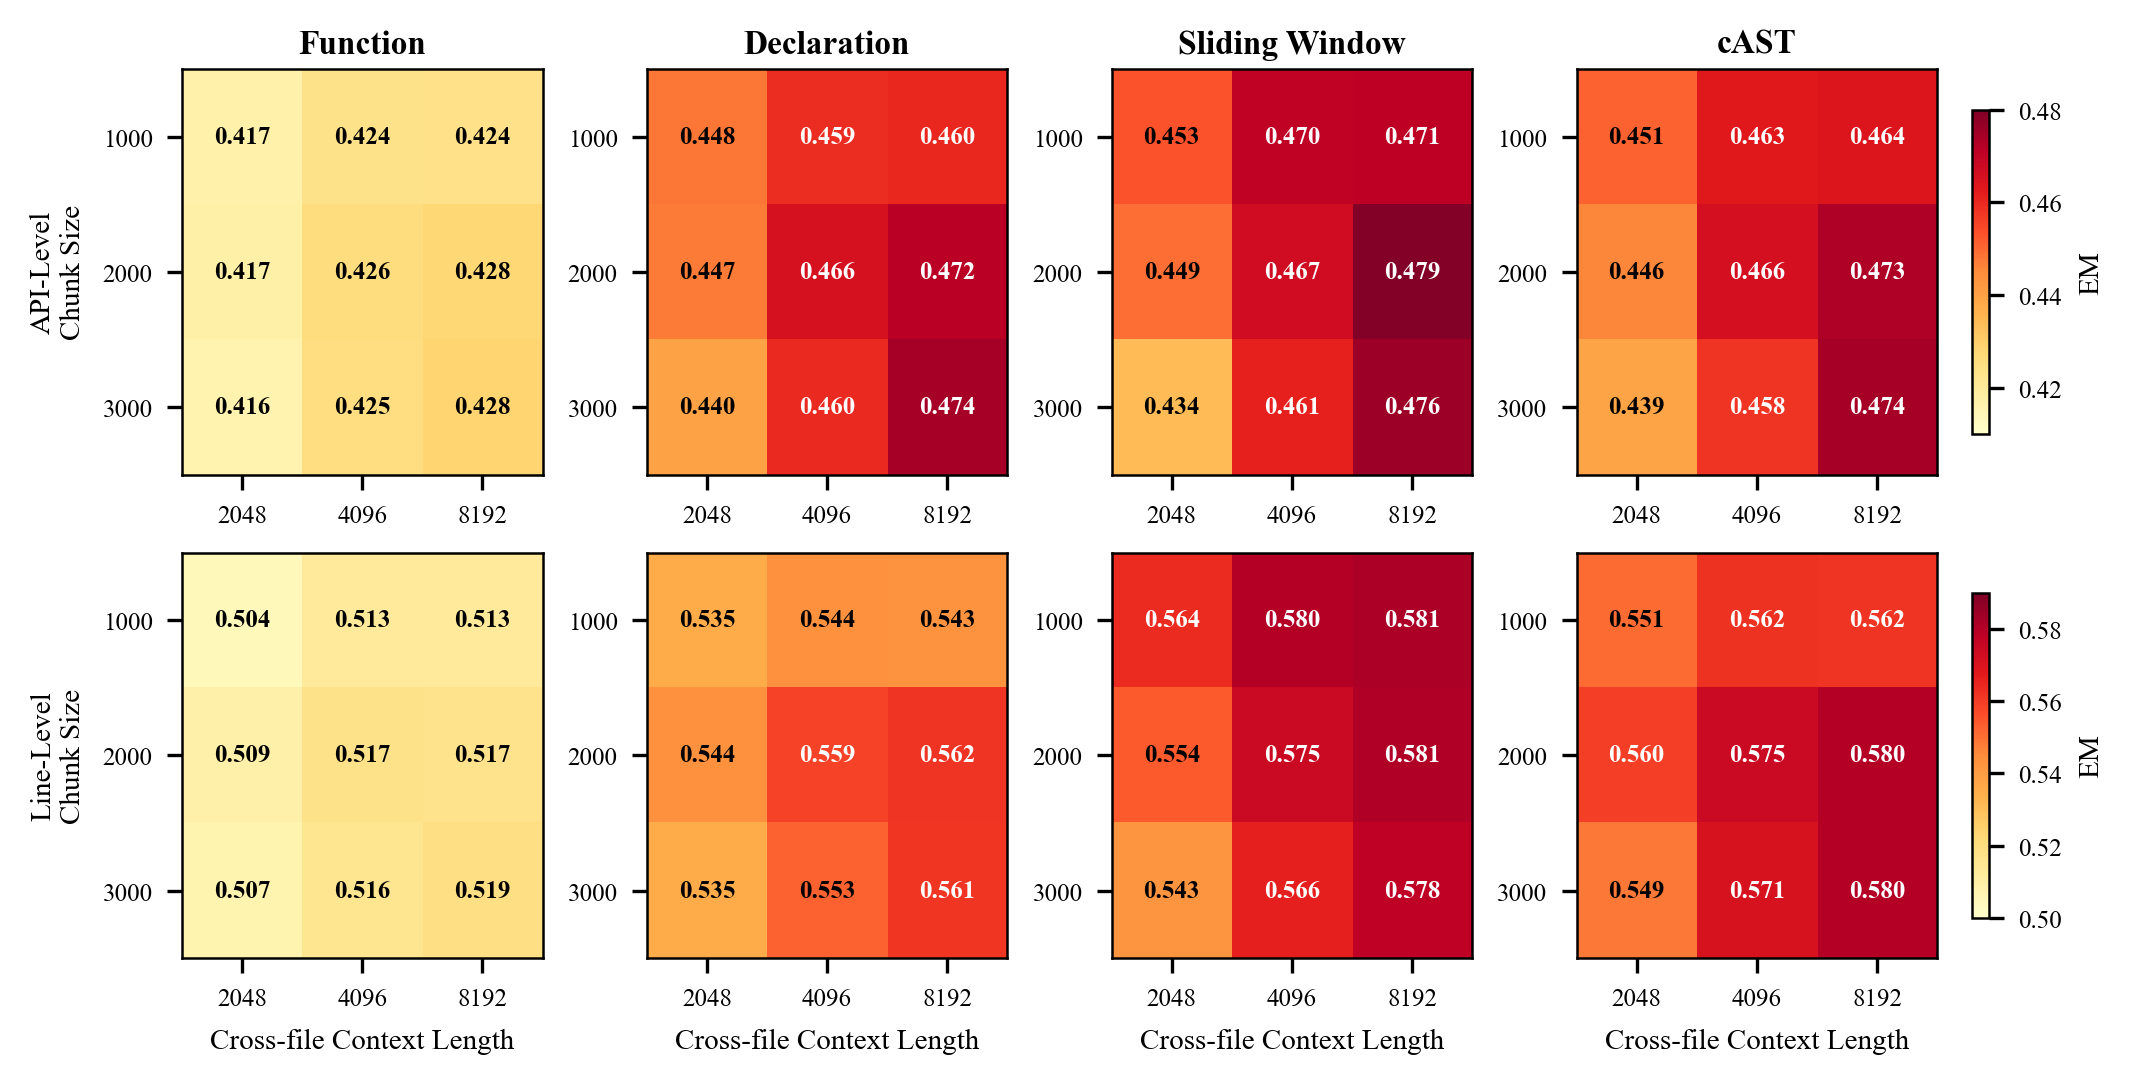

Saved: output/rq3_heatmap.pdf


In [103]:
# RQ3 — Heatmap: chunk_size × cross-file context length per strategy (2×4 grid)
# Style adapted from Chunk-legacy/eval/repoeval/visualize_results.ipynb

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
SPLIT_LABELS = {"api": "API-Level", "line": "Line-Level"}
CHUNK_SIZES = [1000, 2000, 3000]
CONTEXT_LENS = [2048, 4096, 8192]
METRIC = "EM"

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.6,
})

# Pre-compute all grids
grids = {}
all_vals = {s: [] for s in ["api", "line"]}
for split_name in ["api", "line"]:
    sub = rag[rag["split"] == split_name]
    for method in METHOD_ORDER:
        m = sub[sub["method"] == method]
        grid = np.zeros((len(CHUNK_SIZES), len(CONTEXT_LENS)))
        for r, cs in enumerate(CHUNK_SIZES):
            for c, cl in enumerate(CONTEXT_LENS):
                vals = m[(m["max_chunk_size"] == cs) & (m["max_crossfile_context"] == cl)][METRIC].values
                grid[r, c] = np.mean(vals) if len(vals) > 0 else 0
                all_vals[split_name].append(grid[r, c])
        grids[(split_name, method)] = grid

fig, axes = plt.subplots(2, 4, figsize=(7, 3.5), constrained_layout=True)

for row_idx, split_name in enumerate(["api", "line"]):
    vmin = np.floor(min(all_vals[split_name]) * 100) / 100
    vmax = np.ceil(max(all_vals[split_name]) * 100) / 100
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.YlOrRd

    for col_idx, (method, mlabel) in enumerate(zip(METHOD_ORDER, METHOD_LABELS)):
        ax = axes[row_idx, col_idx]
        grid = grids[(split_name, method)]

        im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto")

        for r in range(len(CHUNK_SIZES)):
            for c in range(len(CONTEXT_LENS)):
                val = grid[r, c]
                text_color = "white" if norm(val) > 0.65 else "black"
                ax.text(c, r, f"{val:.3f}", ha="center", va="center",
                        fontsize=6, color=text_color, fontweight="bold")

        ax.set_xticks(range(len(CONTEXT_LENS)))
        ax.set_xticklabels([str(c) for c in CONTEXT_LENS], fontsize=6)
        ax.set_yticks(range(len(CHUNK_SIZES)))
        ax.set_yticklabels([str(c) for c in CHUNK_SIZES], fontsize=6)

        if row_idx == 1:
            ax.set_xlabel("Cross-file Context Length", fontsize=7)
        if col_idx == 0:
            ax.set_ylabel(f"{SPLIT_LABELS[split_name]}\nChunk Size", fontsize=7)

        if row_idx == 0:
            ax.set_title(mlabel, fontweight="bold", fontsize=8, pad=4)

    # Colorbar per row
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[row_idx, :], shrink=0.8, pad=0.02, aspect=20)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label(METRIC, fontsize=7)

fig.savefig(OUTPUT_DIR / "rq3_heatmap.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/rq3_heatmap.pdf")

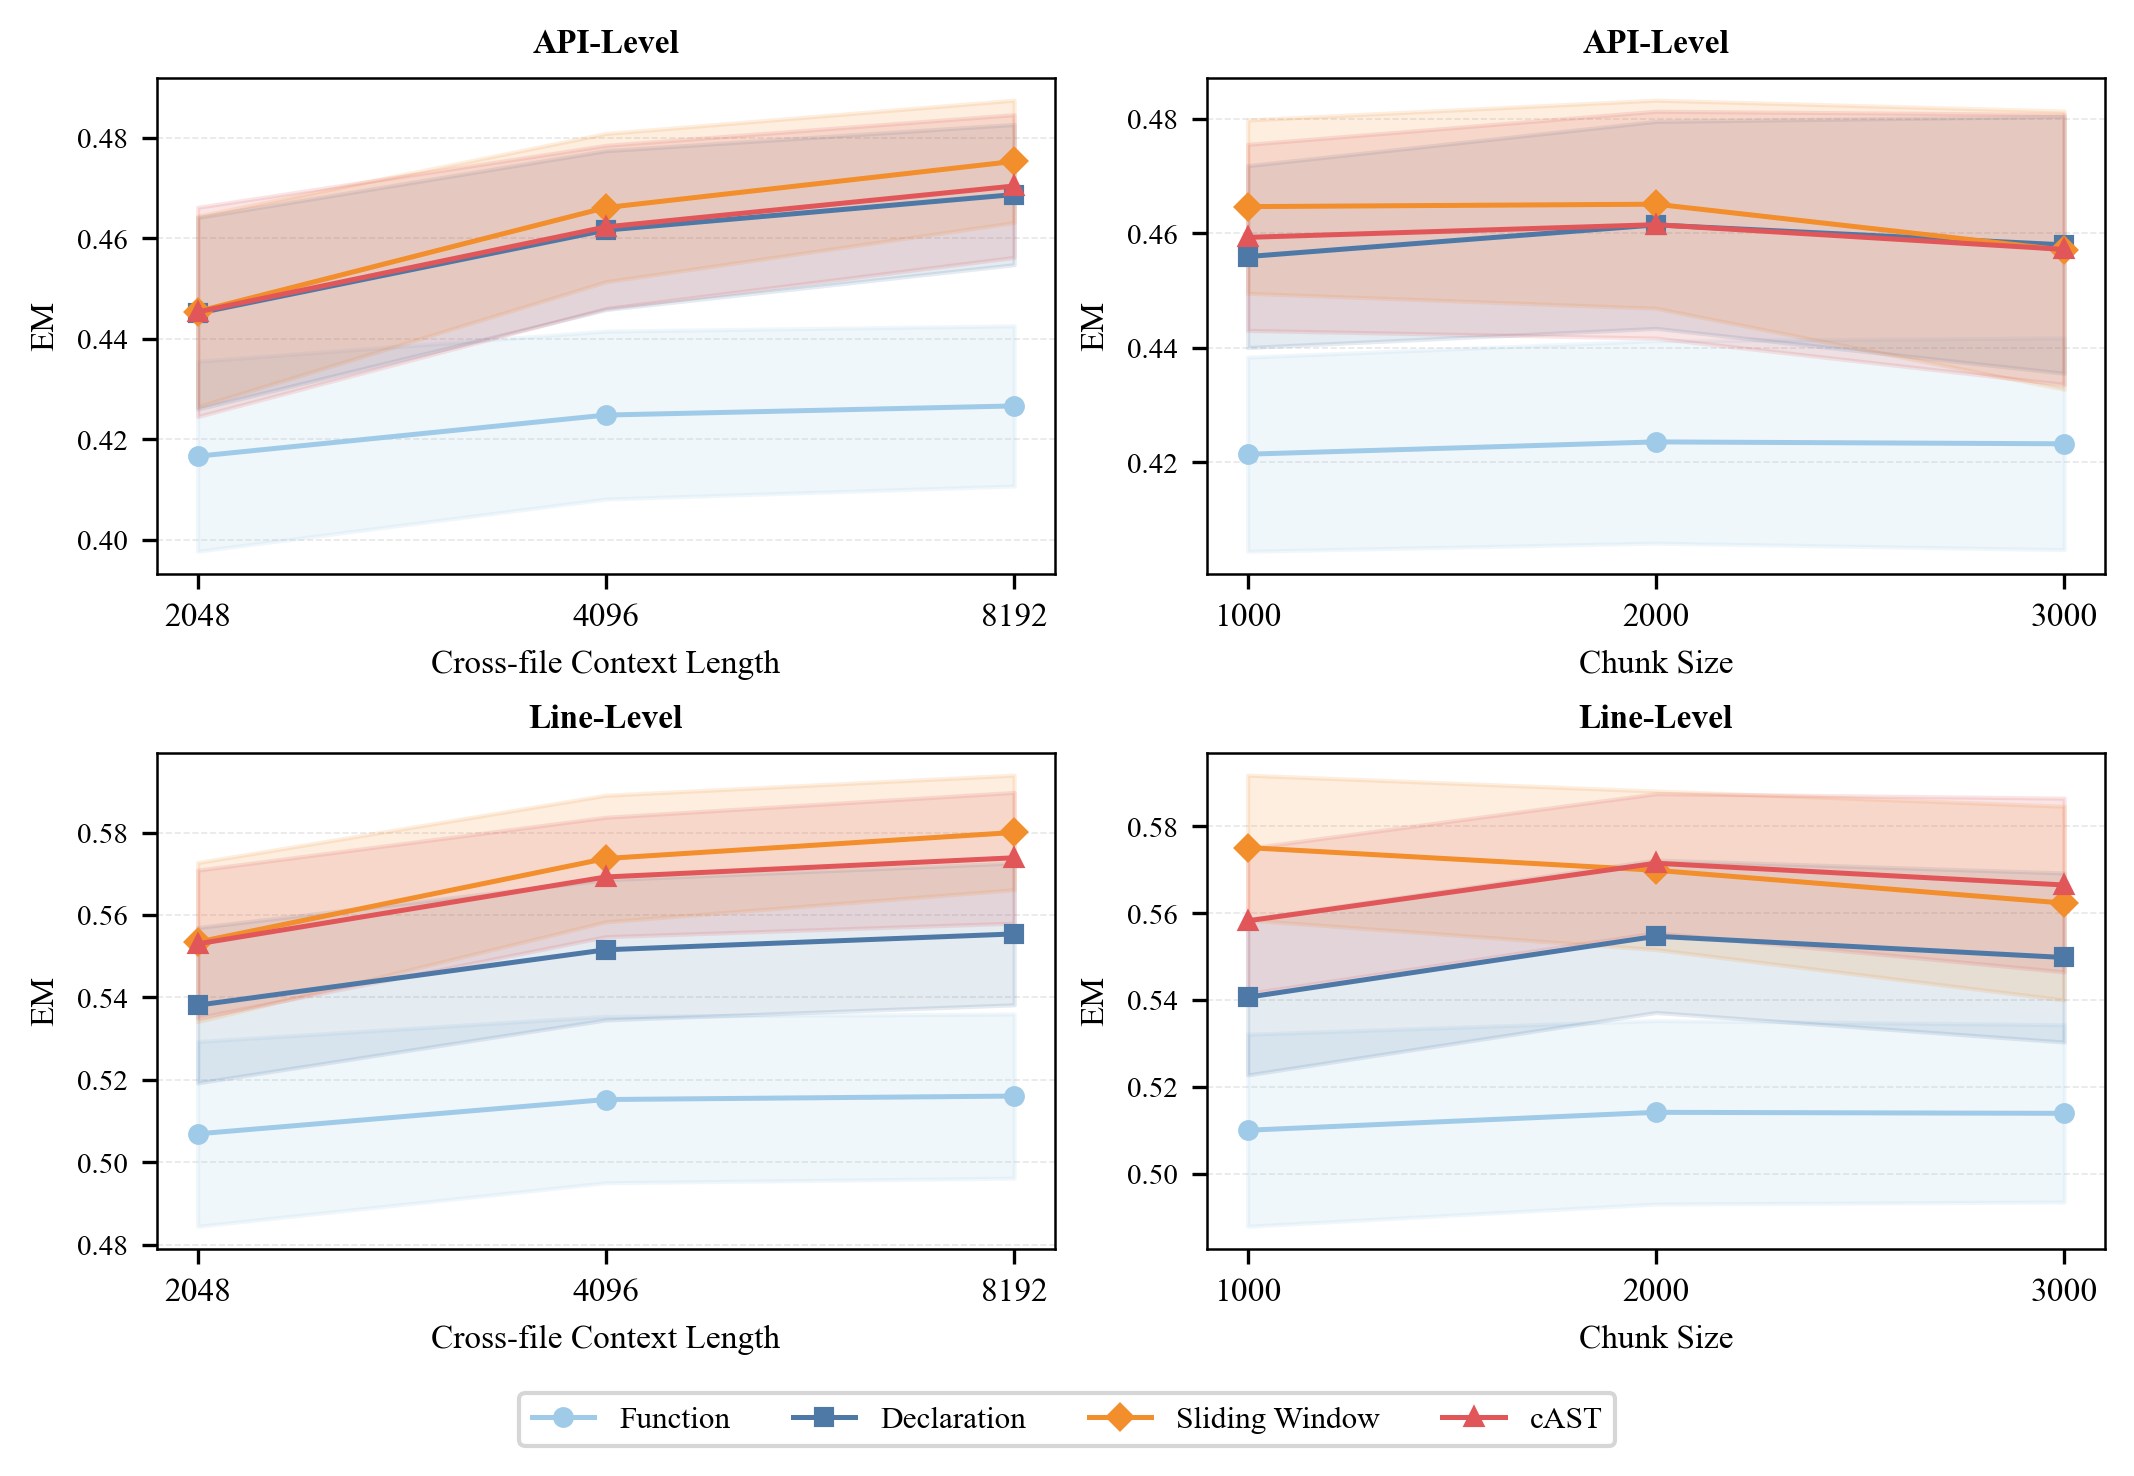

Saved: output/rq3_line.pdf


In [104]:
# RQ3 — Line chart: parameter sensitivity (2×2 grid)
# Style adapted from Chunk-legacy/eval/repoeval/visualize_results.ipynb
# Layout: 2 rows (API / Line) × 2 cols (Cross-file Context Length / Chunk Size)
# 4 method lines with ±1 std shaded bands, aggregated over retriever × LLM.

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
METHOD_COLORS = ['#A0CBE8', '#4E79A7', '#F28E2B', '#E15759']
METHOD_MARKERS = ['o', 's', 'D', '^']
CHUNK_SIZES = [1000, 2000, 3000]
CONTEXT_LENS = [2048, 4096, 8192]
METRIC = "EM"

splits = [
    (rag[rag["split"] == "api"], "API-Level"),
    (rag[rag["split"] == "line"], "Line-Level"),
]

fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), constrained_layout=True)

for row_idx, (sub, task_label) in enumerate(splits):
    # Left column: X = cross-file context length, averaged over chunk size
    ax = axes[row_idx, 0]
    for i, (method, mlabel, color, marker) in enumerate(
        zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS)
    ):
        m = sub[sub["method"] == method]
        means, stds = [], []
        for cl in CONTEXT_LENS:
            vals = m[m["max_crossfile_context"] == cl][METRIC].values
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        means, stds = np.array(means), np.array(stds)
        ax.plot(range(len(CONTEXT_LENS)), means, color=color, marker=marker,
                markersize=4, linewidth=1.2, label=mlabel, zorder=3)
        ax.fill_between(range(len(CONTEXT_LENS)), means - stds, means + stds,
                        color=color, alpha=0.15, zorder=1)
    ax.set_xticks(range(len(CONTEXT_LENS)))
    ax.set_xticklabels([str(c) for c in CONTEXT_LENS])
    ax.set_xlabel("Cross-file Context Length", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(task_label, fontweight="bold", fontsize=8, pad=6)

    # Right column: X = chunk size, averaged over context length
    ax = axes[row_idx, 1]
    for i, (method, mlabel, color, marker) in enumerate(
        zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS)
    ):
        m = sub[sub["method"] == method]
        means, stds = [], []
        for cs in CHUNK_SIZES:
            vals = m[m["max_chunk_size"] == cs][METRIC].values
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        means, stds = np.array(means), np.array(stds)
        ax.plot(range(len(CHUNK_SIZES)), means, color=color, marker=marker,
                markersize=4, linewidth=1.2, label=mlabel, zorder=3)
        ax.fill_between(range(len(CHUNK_SIZES)), means - stds, means + stds,
                        color=color, alpha=0.15, zorder=1)
    ax.set_xticks(range(len(CHUNK_SIZES)))
    ax.set_xticklabels([str(c) for c in CHUNK_SIZES])
    ax.set_xlabel("Chunk Size", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(task_label, fontweight="bold", fontsize=8, pad=6)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.07), frameon=True, edgecolor="#cccccc", fontsize=7.5)

fig.savefig(OUTPUT_DIR / "rq3_line.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/rq3_line.pdf")

## RQ4: Cost Trade-off — Scatter Plot

X = avg_token_cost, Y = EM.
Each point = one configuration.
Marker shape = chunking method.
Draw Pareto front connecting non-dominated points.

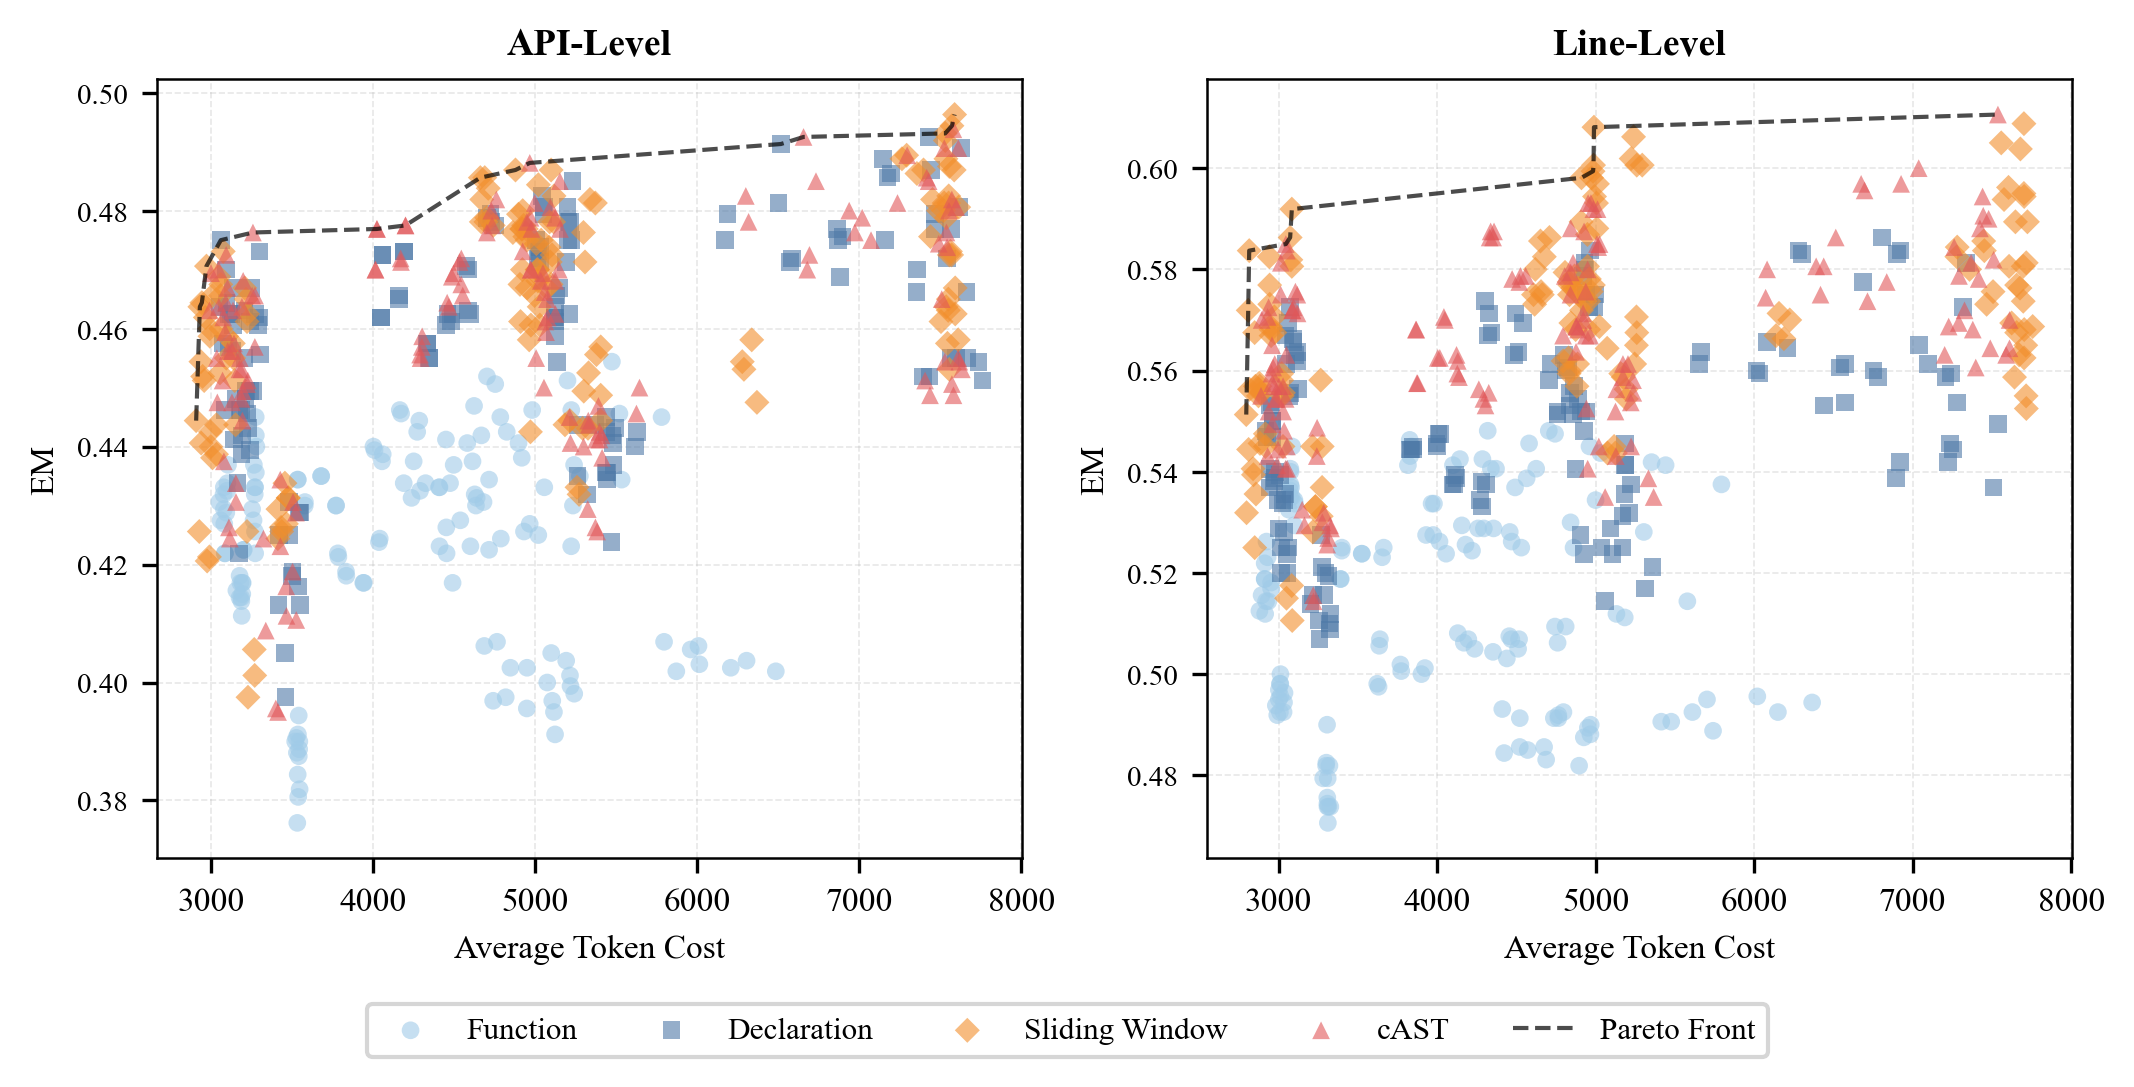

Saved: output/rq4_pareto.pdf


In [105]:
# RQ4 — Cost-performance scatter plot with Pareto front
# Layout: 1 row × 2 cols (API-Level / Line-Level)
# Each point = one configuration (method × retriever × LLM × params)
# Marker shape = chunking method, Pareto front overlaid

METHOD_ORDER = ["function", "declaration", "sliding", "cast"]
METHOD_LABELS = ["Function", "Declaration", "Sliding Window", "cAST"]
METHOD_COLORS = ['#A0CBE8', '#4E79A7', '#F28E2B', '#E15759']
METHOD_MARKERS = ['o', 's', 'D', '^']
METRIC = "EM"
COST_COL = "avg_token_cost"

def pareto_front(costs, scores):
    """Return indices of Pareto-optimal points (lower cost, higher score)."""
    points = list(zip(costs, scores, range(len(costs))))
    points.sort(key=lambda x: x[0])  # sort by cost ascending
    front = []
    best_score = -np.inf
    for cost, score, idx in points:
        if score > best_score:
            front.append(idx)
            best_score = score
    return front

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), constrained_layout=True)

for col_idx, split_name in enumerate(["api", "line"]):
    ax = axes[col_idx]
    sub = rag[rag["split"] == split_name]

    # Aggregate: each unique (method, retriever, llm, chunk_size, context_len) → mean EM, mean cost
    agg = sub.groupby(["method", "retriever", "llm", "max_chunk_size", "max_crossfile_context"]).agg(
        em=(METRIC, "mean"),
        cost=(COST_COL, "mean"),
    ).reset_index()

    # Plot each method
    for method, mlabel, color, marker in zip(METHOD_ORDER, METHOD_LABELS, METHOD_COLORS, METHOD_MARKERS):
        m = agg[agg["method"] == method]
        ax.scatter(m["cost"], m["em"], c=color, marker=marker,
                   s=18, alpha=0.6, label=mlabel, edgecolors="none", zorder=2)

    # Compute and plot global Pareto front
    all_costs = agg["cost"].values
    all_ems = agg["em"].values
    front_idx = pareto_front(all_costs, all_ems)
    front_costs = all_costs[front_idx]
    front_ems = all_ems[front_idx]
    # Sort by cost for line drawing
    sort_order = np.argsort(front_costs)
    ax.plot(front_costs[sort_order], front_ems[sort_order],
            color="black", linewidth=1.0, linestyle="--", alpha=0.7, zorder=3, label="Pareto Front")

    ax.set_xlabel("Average Token Cost", fontsize=8)
    ax.set_ylabel(METRIC, fontsize=8)
    ax.set_title({"api": "API-Level", "line": "Line-Level"}[split_name],
                 fontweight="bold", fontsize=9, pad=6)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.xaxis.grid(True, linestyle="--", alpha=0.3, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.10), frameon=True, edgecolor="#cccccc", fontsize=7.5)

fig.savefig(OUTPUT_DIR / "rq4_pareto.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved: output/rq4_pareto.pdf")